In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize, least_squares
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from tqdm import tqdm

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

### Settings and input data

In [2]:
# ---- Settings ---- #
np.random.seed(100)

# ---- Input and output files ---- #
growth = Path("../../data/For_statistical_analysis_susceptible_strains.xlsx")

out_params = Path("../../out/Growth_features_estimates.tsv")
out_failed = Path("../../out/Growth_features_estimates_failed_samples.tsv")

# ---- prepare output files (headers) ---- #
out_params.write_text("\t".join(["ID","Method","L","r","t0","L0","H","lag"]) + "\n")
out_failed.write_text("ID\n")

3

In [3]:
# ---- read inputs ---- #
# read data and format
gd = pd.read_excel(growth, index_col=0)
gd.index.name = 'ID_FINAL'
gd_l = gd.reset_index().melt(id_vars='ID_FINAL', var_name='Hours', value_name='OD')
gd_l['Hours'] = gd_l['Hours'].astype(float)

In [4]:
# get sample and replicate
gd_l[['Sample', 'Replicate']] = gd_l['ID_FINAL'].str.rsplit('.', n=1, expand=True)

In [5]:
# all negative ODs to 0
gd_l['OD'] = gd_l['OD'].clip(lower=0)

In [6]:
gd_l

,ID_FINAL,Hours,OD,Sample,Replicate
0,D39_1.1,0.0,0.004500,D39_1,1
1,D39_1.2,0.0,0.006500,D39_1,2
2,D39_dHCS_1.1,0.0,0.005000,D39_dHCS_1,1
3,D39_dHCS_1.2,0.0,0.012000,D39_dHCS_1,2
4,D39_16Pro_1.1,0.0,0.009625,D39_16Pro_1,1
...,...,...,...,...,...
29695,ATCC17619_4Pro_3.2,22.0,0.244250,ATCC17619_4Pro_3,2
29696,ATCC17619_4IgG_3.1,22.0,0.239875,ATCC17619_4IgG_3,1
29697,ATCC17619_4IgG_3.2,22.0,0.235875,ATCC17619_4IgG_3,2
29698,ATCC17619_4IgG_dHCS_3.1,22.0,0.346125,ATCC17619_4IgG_dHCS_3,1


### Define functions

In [7]:
# ---- functions ---- #
# biological function
def lgf(L, r, t0, L0, t):
    """4-parameter logistic function : L0 + (L / (1 + exp(-r*(t - t0))))"""
    t = np.asarray(t)
    return L0 + (L / (1.0 + np.exp(-r * (t - t0))))

# optimization functions
def residuals_sumsq(par, hours, od):
    """Objective for optimizers: sum of squared residuals"""
    pred = lgf(par[0], par[1], par[2], par[3], hours)
    return np.sum((od - pred) ** 2)

def residual_vector(par, hours, od):
    """Residual vector for least_squares (returns obs - pred)"""
    pred = lgf(par[0], par[1], par[2], par[3], hours)
    return od - pred

### Get parameters

In [8]:
gd_l

,ID_FINAL,Hours,OD,Sample,Replicate
0,D39_1.1,0.0,0.004500,D39_1,1
1,D39_1.2,0.0,0.006500,D39_1,2
2,D39_dHCS_1.1,0.0,0.005000,D39_dHCS_1,1
3,D39_dHCS_1.2,0.0,0.012000,D39_dHCS_1,2
4,D39_16Pro_1.1,0.0,0.009625,D39_16Pro_1,1
...,...,...,...,...,...
29695,ATCC17619_4Pro_3.2,22.0,0.244250,ATCC17619_4Pro_3,2
29696,ATCC17619_4IgG_3.1,22.0,0.239875,ATCC17619_4IgG_3,1
29697,ATCC17619_4IgG_3.2,22.0,0.235875,ATCC17619_4IgG_3,2
29698,ATCC17619_4IgG_dHCS_3.1,22.0,0.346125,ATCC17619_4IgG_dHCS_3,1


In [23]:
# ---- main loop across SAMPLEs ----
samples = [s for s in gd_l["Sample"].unique() if s != "Blanc"]

for sample_id in tqdm(samples, desc="samples"): 
    sel_sample_all = gd_l[gd_l["Sample"] == sample_id].sort_values("Hours")
    reps = sel_sample_all["ID_FINAL"].unique()

    # ---- fit models  ---- #
    for idx, rep in enumerate(reps):
        sel_rep = sel_sample_all[sel_sample_all["ID_FINAL"] == rep].sort_values("Hours")
        hours = sel_rep["Hours"].values.astype(float)
        od = sel_rep["OD"].values.astype(float)
        if len(od) == 0:
            with out_failed.open("a") as fh:
                fh.write(f"{sample_id}.{rep}\n")
            continue

        max_idx = np.nanargmax(od)
        Max_time = hours[max_idx]
        Min_time = 0.0
        mask_main = (od <= od.max()) & (hours <= Max_time) & (hours >= Min_time)
        mask_tail = (np.abs(od - od.max()) / od.max() <= 0.05) & (hours > Max_time)
        keep_mask = mask_main | mask_tail

        fit_hours = hours[keep_mask] if keep_mask.sum() >= 4 else hours
        fit_od = od[keep_mask] if keep_mask.sum() >= 4 else od

        x0 = np.array([1.0, 1.0, 1.0, 1.0])
        bounds = [(0.1, 1.0), (1.0, 4.0), (0.0, 10.0), (0.0, 1.0)]
        methods = ["BFGS", "Nelder-Mead", "CG", "Powell", "L-BFGS-B"]

        # optimize minimizing SSR and pick lowest
        best_res = None
        best_ss = np.inf
        best_method = None
        for method in methods:
            try:
                if method == "L-BFGS-B":
                    res = minimize(lambda p: residuals_sumsq(p, fit_hours, fit_od),
                                   x0, method=method, bounds=bounds, options={"maxiter":20000})
                else:
                    res = minimize(lambda p: residuals_sumsq(p, fit_hours, fit_od),
                                   x0, method=method, options={"maxiter":20000})
                if res.success:
                    par = res.x
                    if par[1] > 0 and lgf(par[0], par[1], par[2], par[3], 40) < 2.0:
                        ss = residuals_sumsq(par, fit_hours, fit_od)
                        if ss < best_ss:
                            best_ss = ss
                            best_res = res
                            best_method = method
            except Exception:
                continue

        if best_res is None:
            with out_failed.open("a") as fh:
                fh.write(f"{sample_id}.{rep}\n")
            continue

        # refine with least_squares
        lower = [b[0] for b in bounds]
        upper = [b[1] for b in bounds]
        try:
            lsq = least_squares(lambda p: residual_vector(p, fit_hours, fit_od),
                                best_res.x, bounds=(lower, upper), method="trf",
                                max_nfev=20000, ftol=1e-12, xtol=1e-12)
            par_final = lsq.x
        except Exception:
            par_final = best_res.x

        # compute lag
        # get a smooth set of points for the fitted logistic curve so you can find the lag
        dense_t = np.linspace(fit_hours.min(), fit_hours.max(), 1000)
        # compute predicted OD values at each time point
        dense_od = lgf(par_final[0], par_final[1], par_final[2], par_final[3], dense_t)
        # define a threshold for lag
        # PREVIOUS: threshold = 1.5 * fit_od.min()
        threshold = max(L0 + 0.05*L, 0.01)
        # find the first time above the threshold
        idxs = np.where(dense_od >= threshold)[0]
        lag_value = dense_t[idxs[0]] if len(idxs) > 0 else np.nan

        out_row = {
            "ID": f"{rep}",
            "Method": best_method,
            "L": par_final[0],
            "r": par_final[1],
            "t0": par_final[2],
            "L0": par_final[3],
            "delta.H": par_final[0] + par_final[3],
            "lag": lag_value
        }
        with out_params.open("a") as fh:
            fh.write("\t".join(str(out_row[k]) for k in ["ID","Method","L","r","t0","L0","delta.H","lag"]) + "\n")

print("Done. Outputs produced:")
print(f"- {out_params} ")
print(f"- {out_failed}")

samples:   0%|          | 0/330 [00:01<?, ?it/s]


NameError: name 'L0' is not defined

### Check

In [11]:
gf = pd.read_csv("../../out/Growth_features_estimates_failed_samples.tsv", sep="\t")

In [12]:
ge = pd.read_csv("../../out/Growth_features_estimates.tsv", sep="\t")

In [13]:
gf

,ID


In [14]:
ge

,ID,Method,L,r,t0,L0,H,lag
0,D39_1.D39_1.1,BFGS,0.723305,2.007703,6.481780,0.009661,0.732966,0.000000
1,D39_1.D39_1.2,BFGS,0.740443,1.619135,5.952469,0.005449,0.745392,0.000000
2,D39_dHCS_1.D39_dHCS_1.1,L-BFGS-B,0.669817,1.527635,4.770855,0.004007,0.668824,1.341341
3,D39_dHCS_1.D39_dHCS_1.2,BFGS,0.665998,1.420550,4.662000,0.010114,0.664112,1.555556
4,D39_16Pro_1.D39_16Pro_1.1,BFGS,0.650248,1.527089,5.917013,0.006855,0.655479,0.000000
...,...,...,...,...,...,...,...,...
655,ATCC17619_4Pro_3.ATCC17619_4Pro_3.2,BFGS,0.877604,1.321084,5.166526,0.031027,0.869381,2.585586
656,ATCC17619_4IgG_3. ATCC17619_4IgG_3.1,BFGS,0.697328,1.255046,5.515581,0.055633,0.697086,2.994995
657,ATCC17619_4IgG_3. ATCC17619_4IgG_3.2,BFGS,0.769627,1.202776,5.725213,0.052641,0.768393,3.016016
658,ATCC17619_4IgG_dHCS_3. ATCC17619_4IgG_dHCS_3.1,BFGS,0.705371,1.141188,5.216039,0.087261,0.692507,3.183183


In [15]:
ge['sample'] = ge['ID'].str.split('.').str[0]
mean_per_sample = ge.groupby('sample')[['L', 'r', 't0', 'L0', 'H', 'lag']].mean().reset_index()

In [16]:
mean_per_sample

,sample,L,r,t0,L0,H,lag
0,110,0.930589,1.270123,7.765626,0.022365,0.932121,2.318151
1,1186,0.838956,1.362758,6.010640,-0.003341,0.835178,1.444570
2,1188,0.785111,1.346433,6.022871,-0.007040,0.778071,2.177678
3,1189,0.712033,1.142942,7.899201,0.001205,0.712259,0.910515
4,1193,0.891494,1.456169,5.645099,0.000310,0.889117,1.004630
...,...,...,...,...,...,...,...
106,R6_8Pro_2,0.532589,1.411525,7.329595,0.000988,0.533577,0.000000
107,R6_8Pro_3,0.453667,1.404037,7.584582,-0.001423,0.452245,3.457457
108,R6_dHCS_1,0.582410,1.354927,7.608628,0.005838,0.588249,0.000000
109,R6_dHCS_2,0.613134,1.245177,6.567397,0.004836,0.617970,0.000000


### Exploratory viz

In [19]:
gd_l

,ID_FINAL,Hours,OD,Sample,Replicate
0,D39_1.1,0.0,0.004500,D39_1,1
1,D39_1.2,0.0,0.006500,D39_1,2
2,D39_dHCS_1.1,0.0,0.005000,D39_dHCS_1,1
3,D39_dHCS_1.2,0.0,0.012000,D39_dHCS_1,2
4,D39_16Pro_1.1,0.0,0.009625,D39_16Pro_1,1
...,...,...,...,...,...
29695,ATCC17619_4Pro_3.2,22.0,0.244250,ATCC17619_4Pro_3,2
29696,ATCC17619_4IgG_3.1,22.0,0.239875,ATCC17619_4IgG_3,1
29697,ATCC17619_4IgG_3.2,22.0,0.235875,ATCC17619_4IgG_3,2
29698,ATCC17619_4IgG_dHCS_3.1,22.0,0.346125,ATCC17619_4IgG_dHCS_3,1


NameError: name 'params' is not defined

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following famil

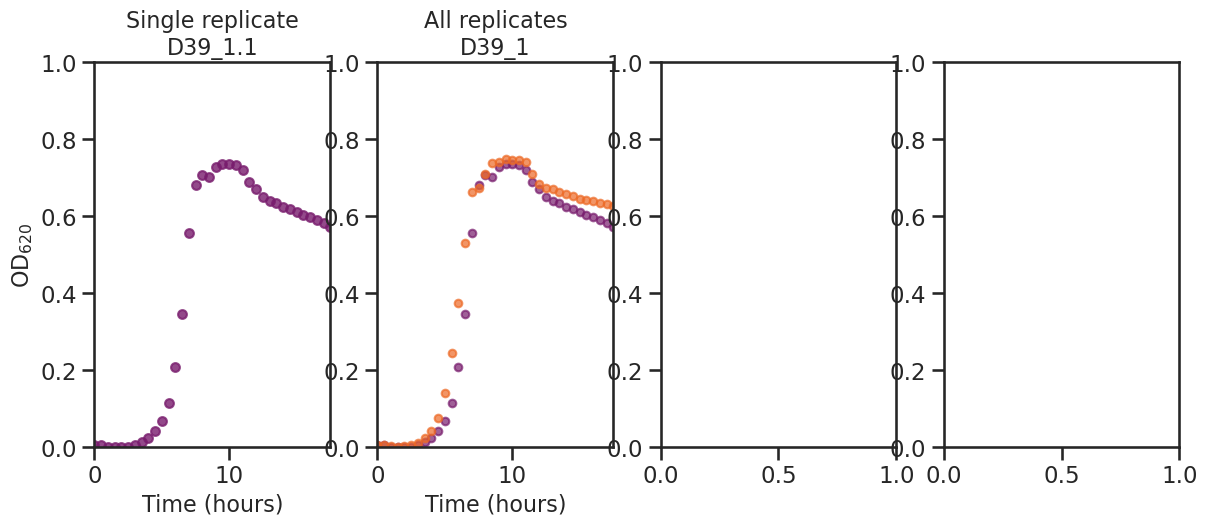

In [21]:
# load fitted parameters
params = pd.read_csv(
    "../../out/Growth_features_estimates.tsv", 
    sep="\t", 
    header=0,   # if your file has a header row; otherwise use skiprows=1 for no header
    dtype={
        "ID": str,
        "Method": str,
        "L": float,
        "r": float,
        "t0": float,
        "L0": float,
        "delta.H": float,
        "lag": float
    }
)

# --- logistic function ---
def lgf(L, r, t0, L0, t):
    t = np.asarray(t)
    return L0 + L / (1 + np.exp(-r*(t - t0)))

# --- mask for fitting only ---
def compute_mask(hours, od):
    max_idx = np.nanargmax(od)
    Max_time = hours[max_idx]
    Min_time = 0.0

    mask_main = (od <= od.max()) & (hours <= Max_time) & (hours >= Min_time)
    mask_tail = (np.abs(od - od.max()) / od.max() <= 0.05) & (hours > Max_time)
    keep_mask = mask_main | mask_tail

    if keep_mask.sum() < 4:
        keep_mask = np.ones_like(od, dtype=bool)
    return keep_mask

# --- loop through all samples ---
samples = [s for s in gd_l["Sample"].unique() if s != "Blanc"]

for sample_id in samples:
    sel_sample_all = gd_l[gd_l["Sample"] == sample_id].copy()
    reps = sel_sample_all["ID_FINAL"].unique()

    fig, axes = plt.subplots(1, 4, figsize=(14, 5))
    axes = axes.flatten()

    palette = sns.color_palette("inferno", len(reps))
    color_single = palette[0]  # first replicate for single panel

    # --- panel 1: single replicate raw ---
    rep_to_plot = reps[0]
    sel_rep_single = sel_sample_all[sel_sample_all["ID_FINAL"] == rep_to_plot].sort_values("Hours")
    ax = axes[0]
    ax.scatter(sel_rep_single["Hours"], sel_rep_single["OD"], color=color_single, s=40, alpha=0.8)
    ax.set_title(f"Single replicate\n{rep_to_plot}", size=16)
    ax.set_xlabel("Time (hours)", size=16)
    ax.set_ylabel(r"OD$_{620}$", size=16)
    ax.set_xlim(0, 17.5)
    ax.set_ylim(0, 1)

    # --- panel 2: all replicates raw ---
    ax = axes[1]
    for idx, rep in enumerate(reps):
        sel_rep = sel_sample_all[sel_sample_all["ID_FINAL"] == rep].sort_values("Hours")
        ax.scatter(sel_rep["Hours"], sel_rep["OD"], color=palette[idx], s=30, alpha=0.7, label=rep)
    ax.set_title(f"All replicates\n{sample_id}", size=16)
    ax.set_xlabel("Time (hours)", size=16)
    ax.set_xlim(0, 17.5)
    ax.set_ylim(0, 1)

    # --- panel 3: fitted curve single replicate ---
    row_single = params[params["ID"] == rep_to_plot].iloc[0]
    L_s, r_s, t0_s, L0_s = row_single["L"], row_single["r"], row_single["t0"], row_single["L0"]
    keep_mask = compute_mask(sel_rep_single["Hours"].values, sel_rep_single["OD"].values)
    fit_hours = sel_rep_single["Hours"].values[keep_mask]
    t_dense = np.linspace(fit_hours.min(), fit_hours.max(), 300)
    y_dense = lgf(L_s, r_s, t0_s, L0_s, t_dense)

    ax = axes[2]
    ax.scatter(sel_rep_single["Hours"], sel_rep_single["OD"], color=color_single, s=30, alpha=0.6)
    ax.plot(t_dense, y_dense, color=color_single, linewidth=2.5)
    ax.set_title(f"Fitted curve\n{rep_to_plot}", size=16)
    ax.set_xlabel("Time (hours)", size=16)
    ax.set_xlim(0, 17.5)
    ax.set_ylim(0, 1)

    # --- panel 4: fitted curves all replicates ---
    ax = axes[3]
    for idx, rep in enumerate(reps):
        sel_rep = sel_sample_all[sel_sample_all["ID_FINAL"] == rep].sort_values("Hours")
        hours = sel_rep["Hours"].values
        od = sel_rep["OD"].values
        ax.scatter(hours, od, s=30, alpha=0.5, color=palette[idx])
        keep_mask = compute_mask(hours, od)
        fit_hours = hours[keep_mask]
        row_rep = params[params["ID"] == rep].iloc[0]
        L_r, r_r, t0_r, L0_r = row_rep["L"], row_rep["r"], row_rep["t0"], row_rep["L0"]
        t_dense_rep = np.linspace(fit_hours.min(), fit_hours.max(), 300)
        y_dense_rep = lgf(L_r, r_r, t0_r, L0_r, t_dense_rep)
        ax.plot(t_dense_rep, y_dense_rep, color=palette[idx], linewidth=2, alpha=0.9, label=rep)
    ax.set_title(f"Fitted curves\n{sample_id}", fontsize=16)
    ax.set_xlabel("Time (hours)", size=16)
    ax.set_xlim(0, 17.5)
    ax.set_ylim(0, 1)

    for ax in axes:
        ax.tick_params(axis='both', labelsize=16)

    plt.tight_layout()
#    plt.savefig(f'../out/figures/growth_curves_{sample_id}.png', dpi=300,
#                bbox_inches='tight', transparent=True)
#    plt.savefig(f'../out/figures/growth_curves_{sample_id}.svg', dpi=300,
#                bbox_inches='tight', transparent=True)
    plt.close(fig)